
Annotation DataFrame created:
           Sample_Group KMeans_Cluster Agg_Cluster GMM_Cluster
SRR1785238           T0       KMeans_0       Agg_1       GMM_0
SRR1785239           T0       KMeans_0       Agg_1       GMM_0
SRR1785240           T0       KMeans_0       Agg_1       GMM_0
SRR1785241           T0       KMeans_0       Agg_1       GMM_0
SRR1785242           T0       KMeans_1       Agg_0       GMM_1

Annotation shape: (88, 4)
Number of annotation columns (n+1): 4

Heatmap data shape: (5000, 88)
Using 5000 genes (top 5000 variable genes)


/Users/I549593/miniforge3/envs/mmds/lib/python3.11/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
/Users/I549593/miniforge3/envs/mmds/lib/python3.11/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


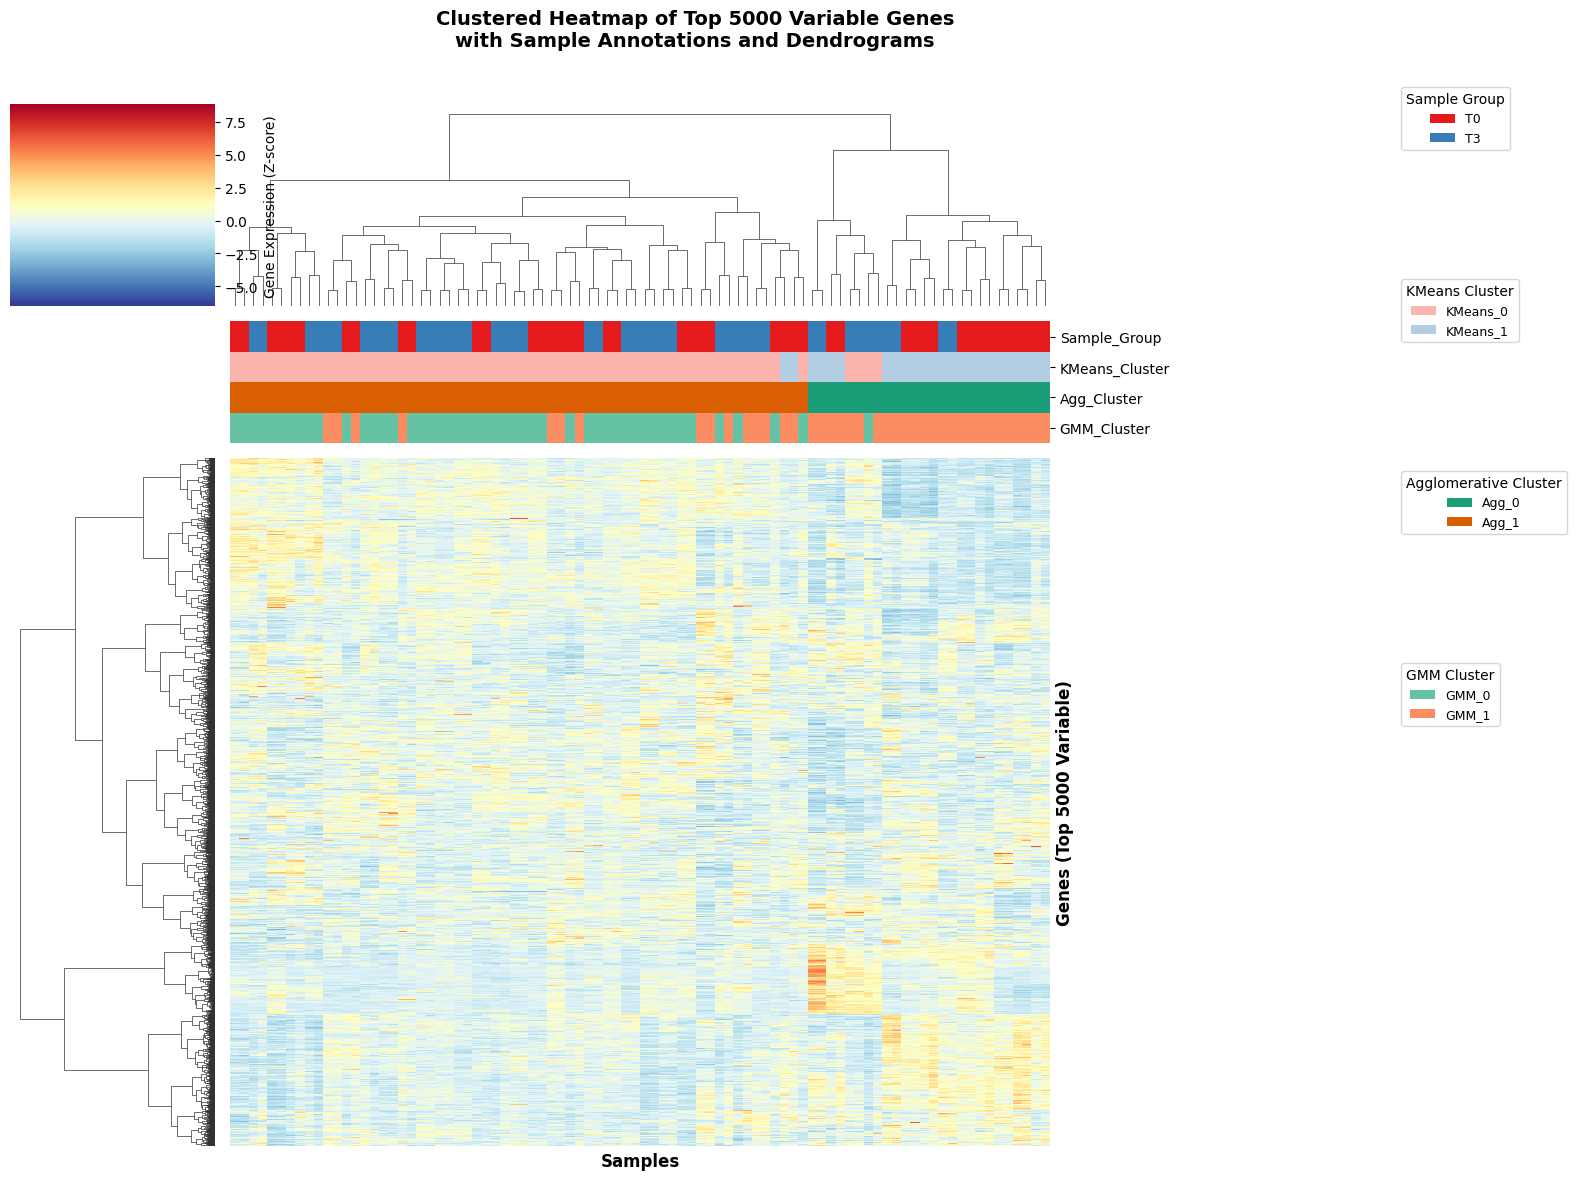

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.mixture import GaussianMixture
from matplotlib.patches import Patch
from sklearn.cluster import KMeans, AgglomerativeClustering

expression_data = pd.read_csv('expression_data.csv')
gene_variances = expression_data.var(axis=1)
top_5000_genes = gene_variances.sort_values(ascending=False).head(5000).index
top_variable_expression = expression_data.loc[top_5000_genes]

data = top_variable_expression.T

scaler = StandardScaler()
scaled_data = scaler.fit_transform(data)

k = 2

kmeans = KMeans(n_clusters=k, random_state=42, n_init=10).fit(scaled_data)
kmeans_labels = [f'KMeans_{l}' for l in kmeans.labels_]

agg = AgglomerativeClustering(n_clusters=k, linkage='ward').fit(scaled_data)
agg_labels = [f'Agg_{l}' for l in agg.labels_]

gmm = GaussianMixture(n_components=k, random_state=42, covariance_type='full').fit(scaled_data)
gmm_cluster_labels = gmm.predict(scaled_data)
gmm_labels = [f'GMM_{l}' for l in gmm_cluster_labels]

group_annotations = pd.read_csv('../data/processed/group_annotation.csv', index_col=0)

annotation_df = pd.DataFrame({
    'Sample_Group': group_annotations['Group'].values,
    'KMeans_Cluster': kmeans_labels,
    'Agg_Cluster': agg_labels,
    'GMM_Cluster': gmm_labels
}, index=group_annotations.index)

print("\nAnnotation DataFrame created:")
print(annotation_df.head())
print(f"\nAnnotation shape: {annotation_df.shape}")
print(f"Number of annotation columns (n+1): {annotation_df.shape[1]}")

sample_group_labels = sorted(annotation_df['Sample_Group'].unique())
kmeans_labels_unique = sorted(annotation_df['KMeans_Cluster'].unique())
agg_labels_unique = sorted(annotation_df['Agg_Cluster'].unique())
gmm_labels_unique = sorted(annotation_df['GMM_Cluster'].unique())

palette1 = sns.color_palette("Set1", len(sample_group_labels))
palette2 = sns.color_palette("Pastel1", len(kmeans_labels_unique))
palette3 = sns.color_palette("Dark2", len(agg_labels_unique))
palette4 = sns.color_palette("Set2", len(gmm_labels_unique))

sample_group_map = dict(zip(sample_group_labels, palette1))
kmeans_map = dict(zip(kmeans_labels_unique, palette2))
agg_map = dict(zip(agg_labels_unique, palette3))
gmm_map = dict(zip(gmm_labels_unique, palette4))

annotation_colors = annotation_df.copy()
annotation_colors['Sample_Group'] = annotation_df['Sample_Group'].map(sample_group_map)
annotation_colors['KMeans_Cluster'] = annotation_df['KMeans_Cluster'].map(kmeans_map)
annotation_colors['Agg_Cluster'] = annotation_df['Agg_Cluster'].map(agg_map)
annotation_colors['GMM_Cluster'] = annotation_df['GMM_Cluster'].map(gmm_map)

heatmap_data = top_variable_expression

print(f"\nHeatmap data shape: {heatmap_data.shape}")
print(f"Using {heatmap_data.shape[0]} genes (top 5000 variable genes)")

g = sns.clustermap(
    heatmap_data,
    cmap='RdYlBu_r',
    col_colors=annotation_colors,
    figsize=(14, 12),
    linewidths=0,
    z_score=0,
    cbar_kws={'label': 'Gene Expression (Z-score)'},
    xticklabels=False,
    yticklabels=False,
    col_cluster=True,
    row_cluster=True,
    method='ward',
    metric='euclidean'
)

g.ax_heatmap.set_xlabel('Samples', fontsize=12, fontweight='bold')
g.ax_heatmap.set_ylabel('Genes (Top 5000 Variable)', fontsize=12, fontweight='bold')

handles1 = [Patch(facecolor=sample_group_map[label], label=label) for label in sample_group_labels]
legend1 = g.fig.legend(handles=handles1, title='Sample Group',
                       bbox_to_anchor=(1.0, 0.92), loc='upper left',
                       frameon=True, fontsize=9)

handles2 = [Patch(facecolor=kmeans_map[label], label=label) for label in kmeans_labels_unique]
legend2 = g.fig.legend(handles=handles2, title='KMeans Cluster',
                       bbox_to_anchor=(1.0, 0.76), loc='upper left',
                       frameon=True, fontsize=9)

handles3 = [Patch(facecolor=agg_map[label], label=label) for label in agg_labels_unique]
legend3 = g.fig.legend(handles=handles3, title='Agglomerative Cluster',
                       bbox_to_anchor=(1.0, 0.60), loc='upper left',
                       frameon=True, fontsize=9)

handles4 = [Patch(facecolor=gmm_map[label], label=label) for label in gmm_labels_unique]
legend4 = g.fig.legend(handles=handles4, title='GMM Cluster',
                       bbox_to_anchor=(1.0, 0.44), loc='upper left',
                       frameon=True, fontsize=9)

g.fig.suptitle('Clustered Heatmap of Top 5000 Variable Genes\nwith Sample Annotations and Dendrograms', 
               y=0.98, fontsize=14, fontweight='bold')

g.fig.tight_layout(rect=[0, 0, 0.85, 0.96])

plt.show()
